In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget
from astropy.io import fits
from matplotlib import colors
import matplotlib.patches as patches
from matplotlib.colors import LogNorm
from matplotlib.patches import Ellipse
from ellipse import LsqEllipse

In [2]:
wray_fits = fits.open('WRAY_15-1880_SPHERE_2021-05-16_H.fits')
wray_hdu = wray_fits[0]
wray_hdu.header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -32 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                 1024                                                  
NAXIS2  =                 1024                                                  
NAXIS3  =                    6                                                  
DATE    = '2021-05-16'         / observation date UTC (CCCC-MM-DD)              
RA      =           280.740984 / 18:42:57.84                                    
DEC     =            -35.54494 / -35:32:41.78                                   
RA_SIM  = '18 42 57.9812'      / Refined Simbad coordinates of target           
DEC_SIM = '-35 32 42.824'      / Refined Simbad coordinates of target           
EPOCH   =               2000.0 / Target Coordinate Epoch                        
SCALE   =               12.2

In [3]:
wray_data = wray_hdu.data
wray_qphi = wray_data[1, :, :]

print (np.shape(wray_data), np.shape(wray_qphi))

(6, 1024, 1024) (1024, 1024)


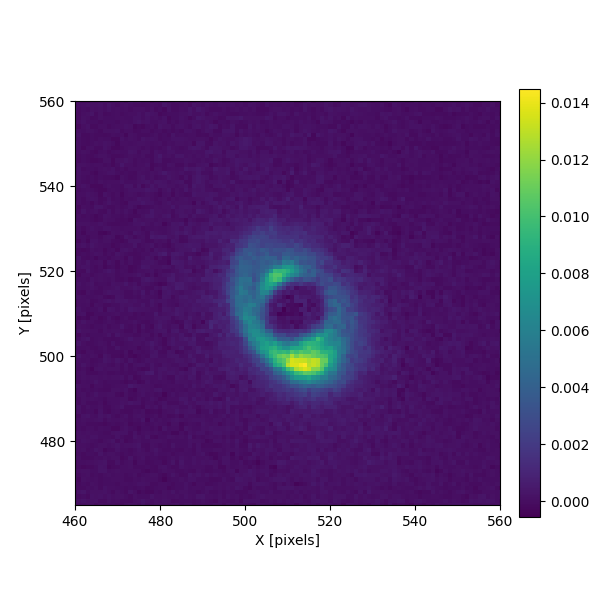

In [4]:
plt.figure(figsize=(6,6))
plt.imshow(wray_qphi, origin='lower')
plt.colorbar(fraction=0.046, pad=0.04)
plt.xlim(460, 560)
plt.ylim(465, 560)
plt.xlabel('X [pixels]')
plt.ylabel('Y [pixels]')
plt.show()

Now we build the **mask**:

In [5]:
mask = np.ones([1024, 1024])
ylen, xlen = np.shape(mask)
X_axis = np.arange(0, xlen, 1)
Y_axis = np.arange(0, ylen, 1)
X, Y = np.meshgrid(X_axis, Y_axis)

scale = wray_hdu.header['SCALE'] # number of mas/px

x_center = 511.5
y_center = 511.5
radius = 92.5/scale  # width of the coronograph in pixels: the coronograph has a radius of 92.5 mas

target_distance = np.sqrt((X-x_center)**2 + (Y-y_center)**2)
aperture_selection = (target_distance < radius)

mask[aperture_selection] = 0

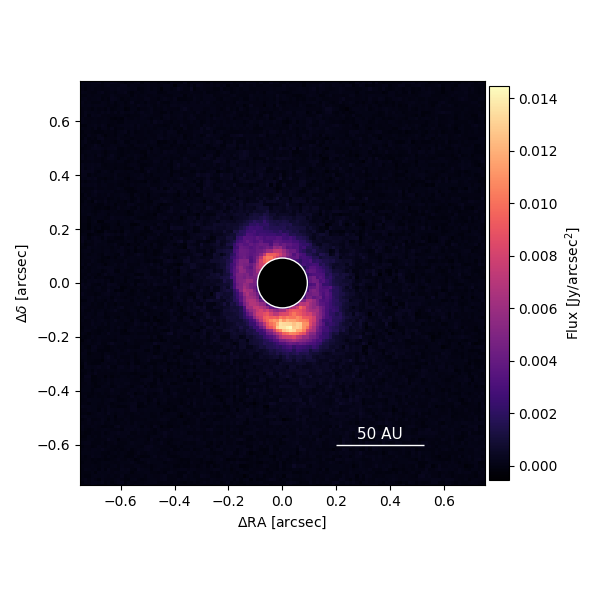

In [6]:
# Define circle parameters
scale = wray_hdu.header['SCALE']/1000. # number of arcsec/px

extent = [
    -wray_qphi.shape[1] * scale / 2,  # Left = -width/2 (as)
    wray_qphi.shape[1] * scale / 2,   # Right = +width/2 (as)
    -wray_qphi.shape[0] * scale / 2,  # Bottom = -height/2 (as)
    wray_qphi.shape[0] * scale / 2,   # Top = +height/2 (as)
]

# Create a black circle with white edges
circle = patches.Circle(
    (0, 0),  # Center position
    0.0925,                # Radius
    edgecolor='white',     # White circumference
    facecolor='black',     # Black fill
    linewidth=1,           # Line thickness
    alpha=1              # Optional: transparency (0-1)
)

# Add a white 100 mas scale bar (adjust position as needed)
scale_bar_length = 0.3247  # as
scale_bar_height = 0.0004    # as (thickness of the bar)
scale_bar_x = 0.2       # x-position (as)
scale_bar_y = -0.6       # y-position (as)

# Create a white rectangle
scale_bar = patches.Rectangle(
    (scale_bar_x, scale_bar_y),   # (x, y) position
    scale_bar_length,             # width (as)
    scale_bar_height,             # height (as)
    linewidth=1, edgecolor='white', facecolor='white'
)

plt.figure(figsize=(6, 6))
#plt.imshow(wray_qphi, norm=LogNorm(10**-8, vmax=wray_qphi.max()), origin='lower', cmap='magma', extent=extent)
plt.imshow(wray_qphi, origin='lower', cmap='magma', extent=extent)
plt.colorbar(fraction=0.046, pad=0.01, label=r"Flux [Jy/arcsec$^2$]")
plt.gca().add_patch(scale_bar)

# Optional: Add text label
plt.text(
    scale_bar_x + scale_bar_length / 2,  # x-center of the bar
    scale_bar_y + 0.01,                   # y-position above the bar
"50 AU", 
    color='white', 
    ha='center', 
    va='bottom',
    size=11
)

# Add the circle to the plot
plt.gca().add_patch(circle)

plt.xlabel(r'$\Delta$RA [arcsec]')
plt.ylabel(r'$\Delta\delta$ [arcsec]')
plt.xlim(-0.75, 0.75)
plt.ylim(-0.75, 0.75)
plt.tight_layout()
plt.show()

Now we want to calculate the flux inside a slit that rotates 360 degrees around the center of the disk. However, we first have to **derotate** the image:

In [7]:
from scipy.ndimage import map_coordinates

i = 39.22
PA = 26.35

def deproject_disk(image, inc_deg, pa_astro_deg, order=3):
    """
    Correctly deprojects images with NaN values:
    - Stretches perpendicular to PA by 1/cos(i)
    - Preserves PA axis length
    - Maintains original dimensions
    - Handles existing NaN values properly
    """
    if inc_deg == 0:
        return image.copy()

    # Create mask of non-NaN pixels
    mask = np.isfinite(image)
    image_no_nan = np.where(mask, image, 0)

    ny, nx = image.shape
    center = np.array([(ny-1)/2, (nx-1)/2])
    y, x = np.indices((ny, nx))
    coords = np.vstack([y.ravel() - center[0], x.ravel() - center[1]])

    # Convert PA (North-to-West) to math convention
    theta = np.radians(pa_astro_deg)
    stretch = 1 / np.cos(np.radians(inc_deg))

    # Rotation matrix
    c, s = np.cos(theta), np.sin(theta)
    rot_matrix = np.array([[c, -s], [s, c]])

    # Transform coordinates
    aligned = rot_matrix @ coords
    aligned[1] /= stretch  # Correct stretching direction
    final_coords = rot_matrix.T @ aligned
    final_coords += center[:, None]

    # Interpolate image and mask separately
    deprojected = map_coordinates(image_no_nan, final_coords, 
                                order=order, mode='constant', cval=np.nan)
    mask_deprojected = map_coordinates(mask.astype(float), final_coords,
                                    order=0, mode='constant', cval=0)

    # Combine results
    result = deprojected.reshape((ny, nx))
    result[mask_deprojected.reshape((ny, nx)) < 0.5] = np.nan
    
    return result
    
#little = wray_qphi.byteswap().newbyteorder() # converting the image to little-endian type order
wray_qphi_d = deproject_disk(wray_qphi, i, PA) # we put the position angle and the inclination we found with ALMA data
np.shape(wray_qphi_d)

(1024, 1024)

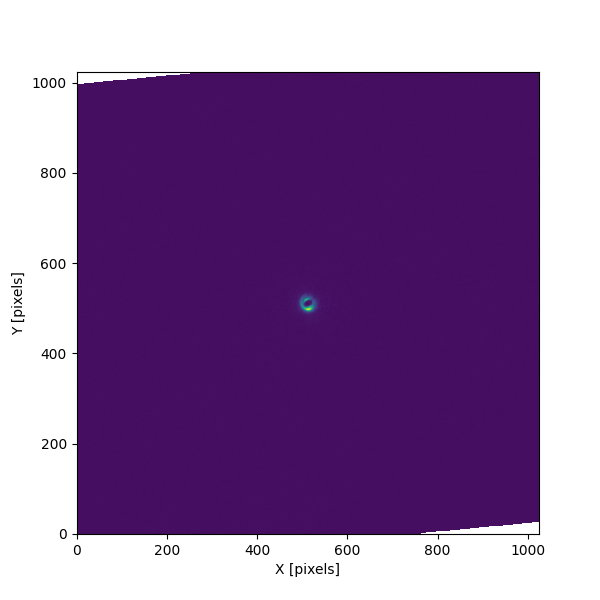

In [8]:
plt.figure(figsize=(6,6))
plt.imshow(wray_qphi_d, origin='lower')
plt.xlabel('X [pixels]')
plt.ylabel('Y [pixels]')
plt.show()

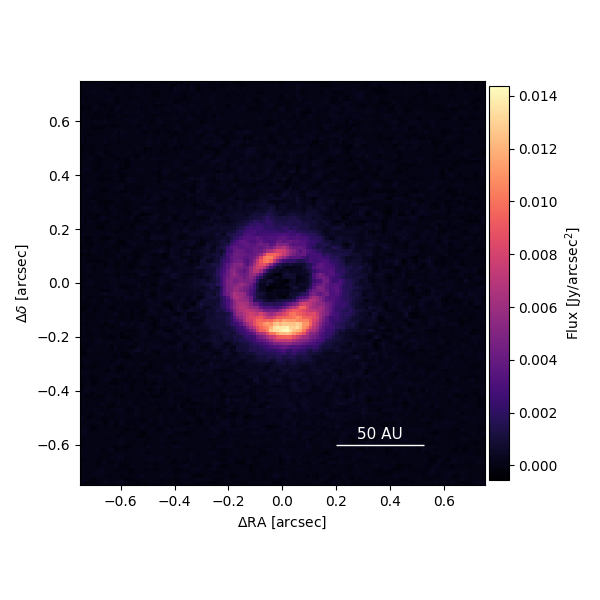

In [9]:
from matplotlib.colors import AsinhNorm

# Let us see the deprojeccted disk image:
# Define circle parameters
scale = wray_hdu.header['SCALE']/1000. # number of arcsec/px

extent = [
    -wray_qphi.shape[1] * scale / 2,  # Left = -width/2 (as)
    wray_qphi.shape[1] * scale / 2,   # Right = +width/2 (as)
    -wray_qphi.shape[0] * scale / 2,  # Bottom = -height/2 (as)
    wray_qphi.shape[0] * scale / 2,   # Top = +height/2 (as)
]

# Add a white 100 mas scale bar (adjust position as needed)
scale_bar_length = 0.3247  # as
scale_bar_height = 0.0004    # as (thickness of the bar)
scale_bar_x = 0.2       # x-position (as)
scale_bar_y = -0.6       # y-position (as)

# Create a white rectangle
scale_bar = patches.Rectangle(
    (scale_bar_x, scale_bar_y),   # (x, y) position
    scale_bar_length,             # width (as)
    scale_bar_height,             # height (as)
    linewidth=1, edgecolor='white', facecolor='white'
)

circle = plt.Circle((0, 0), 0.214, edgecolor='white', facecolor='none', linewidth=0.7)

plt.figure(figsize=(6, 6))
plt.imshow(wray_qphi_d, origin='lower', cmap='magma', extent=extent)
plt.colorbar(fraction=0.046, pad=0.01, label=r"Flux [Jy/arcsec$^2$]")
plt.gca().add_patch(scale_bar)

# Optional: Add text label
plt.text(
    scale_bar_x + scale_bar_length / 2,  # x-center of the bar
    scale_bar_y + 0.01,                   # y-position above the bar
"50 AU", 
    color='white', 
    ha='center', 
    va='bottom',
    size=11
)

#plt.gca().add_patch(circle)
plt.xlabel(r'$\Delta$RA [arcsec]')
plt.ylabel(r'$\Delta\delta$ [arcsec]')
plt.xlim(-0.75, 0.75)
plt.ylim(-0.75, 0.75)
plt.tight_layout()
plt.show()

Here we plot the **(r, $\phi$)** image:

In [10]:
import skimage
from skimage.transform import warp_polar, rotate

# Rotate the image by 90 degrees clockwise first
wray_qphi_rotated = rotate(wray_qphi_d, angle=90, resize=False)

# Compute polar transform
wray_qphi_polar = warp_polar(
    wray_qphi_rotated,
    radius=512,               # Radial resolution (512 pixels)
    scaling='linear',         # Linear or 'log' for log-radius
).T # transpose final matrix

wray_qphi_polar_extended = np.zeros([512, 540])

# Get the slices from columns instead
left_part = wray_qphi_polar[:, 270:360]      # Last 90 columns (270-360)
right_part = wray_qphi_polar[:, 0:90]        # First 90 columns (0-90)

# Assemble the new image
# Left part (last 90 columns)
wray_qphi_polar_extended[:, :90] = left_part
# Original image in center
wray_qphi_polar_extended[:, 90:90+360] = wray_qphi_polar
# Right part (first 90 columns)
wray_qphi_polar_extended[:, 90+360:] = right_part

print (np.shape(wray_qphi_polar_extended))

(512, 540)


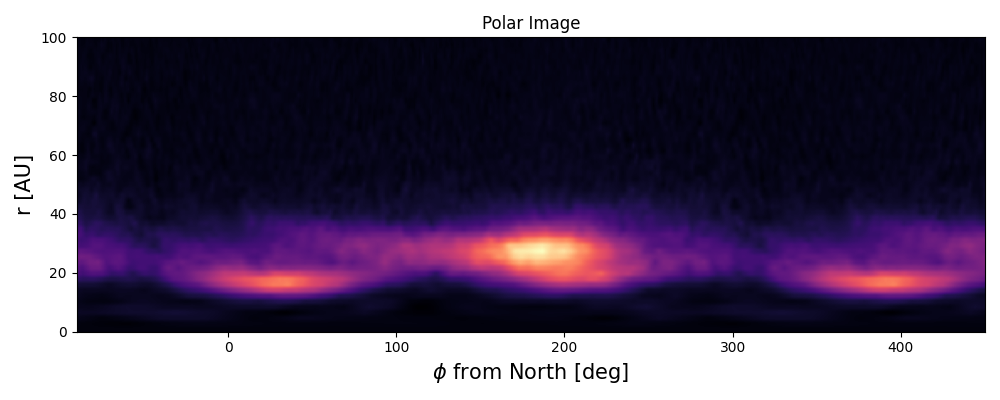

In [11]:
AU_scale = 1.89 # AU/pixel (at a distance of 154 pc)
p_extent = [-90, 450, 0, wray_qphi_polar_extended.shape[0] * AU_scale]

plt.figure(figsize=(10, 4))
#plt.imshow(wray_qphi_polar_extended, origin='lower', cmap='magma', extent=p_extent, aspect='auto', norm=LogNorm(vmin=10**-7.8, vmax=np.nanmax(wray_qphi_d)))
plt.imshow(wray_qphi_polar_extended, origin='lower', cmap='magma', extent=p_extent, aspect='auto')
plt.xlabel('$\phi$ from North [deg]', fontsize=15)
plt.ylabel('r [AU]', fontsize=15)
plt.ylim(0, 100)
plt.title('Polar Image')
plt.tight_layout()
plt.show()

We can analyze this image: first of all, we see a **spiral arm**, which can be investigated: is it actually a spiral or perhaps the **inner part of the ring** that we see in ALMA? Actually, if it was a ring, the pitch angle should be zero, but we see by eye that it is not. We also know from ALMA data (see the professor paper) that the disk rotates **counter-clockwise**, and this would be in agreement with the winding of the spiral arm. We could do a fit inside an **ellipse** of this spiral and see if it is an **archimedean** or **log-log** spiral. Could it be due to the presence of a **planet**? According to our data, could we give an approximate **position** of this object (for example by calculating the distance of the base of the spiral)?

Then we have the **speckles**, and we can say that they are speckles because they are found **around the coronagraph** (see the non-deprojected image) and they are located exactly at 180 degrees distance from each other.

We can also say something about the **blob**: we have seen before that its peak is located at 191.2 degrees from North; it has an extension of about 45-50 degrees (we can see this from a fit, perhaps) and appears to be horizontal in the (r, $\phi$) plot, therefore it does not seem to be part of the spiral arm, and in general does not seem to be a spiral arm. Could it be a blob due to **gravitational perturbation** by a planet (see something in the literature)?

What about the cartesian deprojected image? It looks like the west side is more luminous than the east side. Perhaps the west side is closer? Are there **shadowing** effects? See something in the literature. We could also try to **look at the asymmetries** by subtracting one half of the image with the other half.

In [12]:
import pickle

pickle.dump(wray_qphi, open('wray_qphi', 'wb'))
pickle.dump(wray_qphi_d, open('wray_qphi_d', 'wb'))
pickle.dump(wray_qphi_polar_extended, open('wray_qphi_polar_extended', 'wb'))